# TP4 - Análisis de Componentes Principales (PCA)
## Dataset: Características económicas, sociales y geográficas de 28 países de Europa

**Variables:**
- `Area`: Superficie del país (km²)
- `GDP`: Producto Bruto Interno per cápita (USD)
- `Inflation`: Inflación anual (%)
- `Life.expect`: Expectativa de vida media (años)
- `Military`: Gasto militar (% del GDP)
- `Pop.growth`: Tasa de crecimiento poblacional (%)
- `Unemployment`: Tasa de desempleo (%)

## 1. Carga y exploración del dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df = pd.read_csv('europe.csv')
print(df.shape)
df

c:\Users\Yohann Corfdir\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


(28, 8)


,Country,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,Austria,83871,41600,3.5,79.91,0.80,0.03,4.2
1,Belgium,30528,37800,3.5,79.65,1.30,0.06,7.2
2,Bulgaria,110879,13800,4.2,73.84,2.60,-0.80,9.6
3,Croatia,56594,18000,2.3,75.99,2.39,-0.09,17.7
4,Czech Republic,78867,27100,1.9,77.38,1.15,-0.13,8.5
5,Denmark,43094,37000,2.8,78.78,1.30,0.24,6.1
6,Estonia,45228,20400,5.0,73.58,2.00,-0.65,12.5
7,Finland,338145,36000,3.3,79.41,2.00,0.07,7.8
8,Germany,357022,38100,2.5,80.19,1.50,-0.20,6.0
9,Greece,131957,26300,3.3,80.05,4.30,0.06,17.4


In [3]:
df.describe().round(3)

,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
count,28.000,28.000,28.000,28.000,28.000,28.000,28.000
mean,166422.536,31860.714,3.343,78.123,1.606,0.117,9.921
std,165538.676,14502.116,1.398,3.189,0.801,0.502,4.678
min,2586.000,7200.000,0.200,68.740,0.000,-0.800,2.800
25%,48083.250,20350.000,2.575,76.020,1.095,-0.182,6.925
50%,87980.500,30500.000,3.350,79.530,1.500,0.065,8.450
75%,304176.250,38750.000,4.025,80.320,1.925,0.398,12.725
max,603550.000,80600.000,8.000,81.860,4.300,1.140,21.700


## 2. Preprocesamiento

PCA es sensible a la escala y tenemos datos muy grande (eg: Area, GDP) y otros muy chicos (eg : inflation) entonces hay que estandarizar los datos. Para eso usamos standardScaler. 

In [11]:
features = ['Area', 'GDP', 'Inflation', 'Life.expect', 'Military', 'Pop.growth', 'Unemployment']
countries = df['Country'].values

X = df[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).round(3)

,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,-0.508,0.684,0.114,0.571,-1.024,-0.177,-1.246
1,-0.836,0.417,0.114,0.488,-0.389,-0.116,-0.592
2,-0.342,-1.268,0.624,-1.367,1.263,-1.861,-0.070
3,-0.676,-0.973,-0.760,-0.681,0.996,-0.420,1.693
4,-0.539,-0.334,-1.051,-0.237,-0.580,-0.501,-0.309
5,-0.759,0.361,-0.395,0.210,-0.389,0.249,-0.832
6,-0.746,-0.805,1.207,-1.450,0.501,-1.556,0.561
7,1.056,0.291,-0.031,0.411,0.501,-0.096,-0.462
8,1.173,0.438,-0.614,0.660,-0.135,-0.643,-0.854
9,-0.212,-0.390,-0.031,0.615,3.423,-0.116,1.628


## 3. Componentes principales (PCA)

In [6]:
pca = PCA()
scores = pca.fit_transform(X_scaled)

# Varianza explicada
var_exp = pca.explained_variance_ratio_
var_acc = np.cumsum(var_exp)

print('Varianza explicada por cada componente:')
for i, (v, vc) in enumerate(zip(var_exp, var_acc)):
    print(f'  PC{i+1}: {v*100:.2f}%  (acumulada: {vc*100:.2f}%)')

Varianza explicada por cada componente:
  PC1: 46.10%  (acumulada: 46.10%)
  PC2: 16.96%  (acumulada: 63.06%)
  PC3: 15.19%  (acumulada: 78.25%)
  PC4: 11.01%  (acumulada: 89.25%)
  PC5: 6.54%  (acumulada: 95.80%)
  PC6: 2.41%  (acumulada: 98.21%)
  PC7: 1.79%  (acumulada: 100.00%)


El PC1 explica a el mismo el 46.10% la dispersión total de mis datos. 

## 4. Gráficas

### 4.1 varianza explicada por componentes

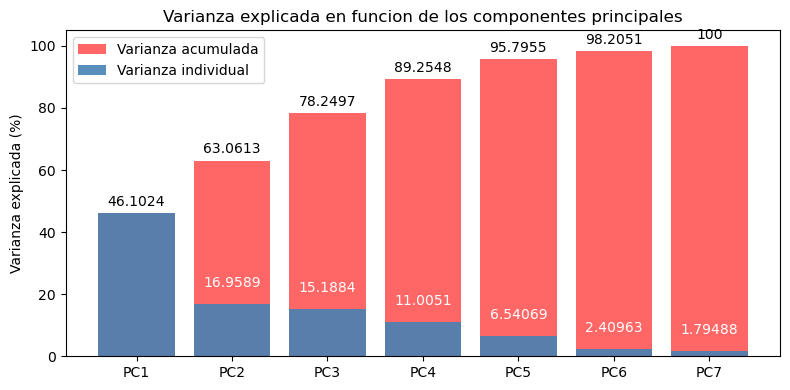

In [7]:
fig, ax = plt.subplots(figsize=(8, 4))
pcs = [f'PC{i+1}' for i in range(len(var_exp))]

barsacc = ax.bar(pcs, var_acc * 100, color='red', alpha = 0.6,label='Varianza acumulada')
ax.bar_label(barsacc, padding=3, color="black")
barsex= ax.bar(pcs, var_exp * 100, color='steelblue', alpha=0.9, label='Varianza individual')
ax.bar_label(barsex, padding=10, color=  "white")
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Varianza explicada en funcion de los componentes principales')
ax.legend()
plt.tight_layout()
plt.show()

### 4.2 Loadings de PC1 (contribución de cada variable)
Los loadings indican cuanto contribuye cada variable original a la combinacion lineal que define cada componente principal. Mas cerca de 1 o -1 implica que la variable influa mucho el componente, cerca de cero que la variable no influa el componente. Si es positivo es que influa positivamente el componente y si es negativo que influa negativamente. 

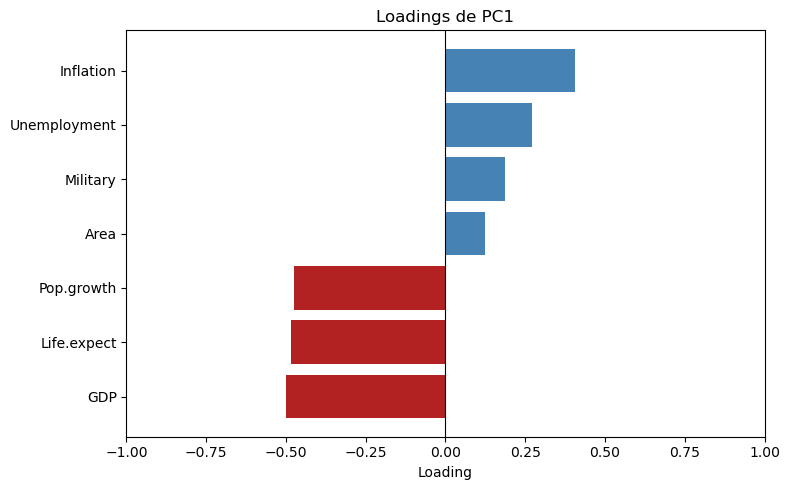


Loadings PC1:
Area            0.1249
GDP            -0.5005
Inflation       0.4065
Life.expect    -0.4829
Military        0.1881
Pop.growth     -0.4757
Unemployment    0.2717
Name: PC1, dtype: float64


In [12]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(len(features))]
)

pc1_loadings = loadings['PC1'].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['firebrick' if v < 0 else 'steelblue' for v in pc1_loadings]
ax.barh(pc1_loadings.index, pc1_loadings.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading')
ax.set_title(f'Loadings de PC1')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

print('\nLoadings PC1:')
print(loadings['PC1'].round(4))

Por PC1, las variables que influyen lo mas son GDP, Life.expect, Pop.growth and Inflation. Inflation influa en la direccion opuesta a GDP, Life.expect and Pop.growth. 

### 4.3 Scores de PC1 (posición de cada país)

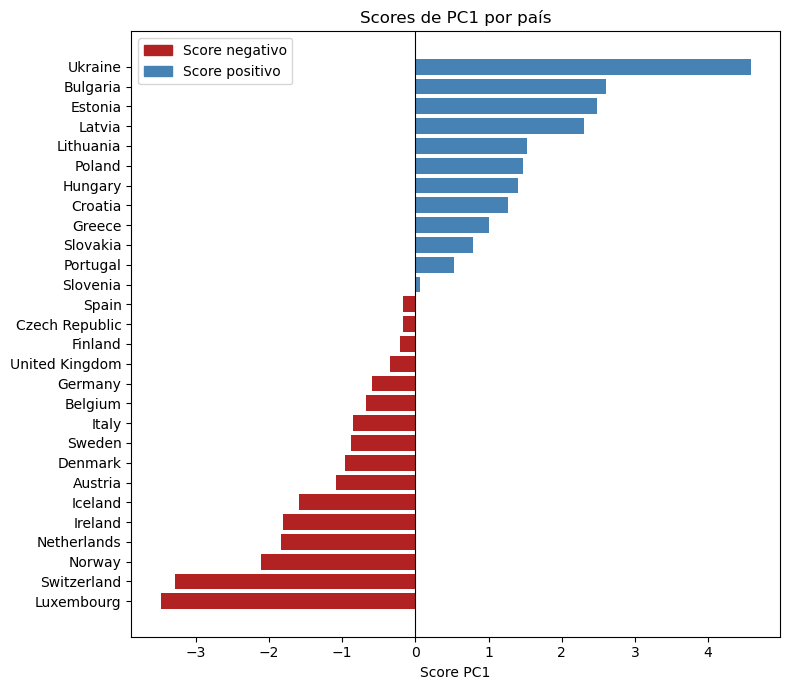

In [13]:
pc1_scores = pd.Series(scores[:, 0], index=countries).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['firebrick' if v < 0 else 'steelblue' for v in pc1_scores]
ax.barh(pc1_scores.index, pc1_scores.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Score PC1')
ax.set_title('Scores de PC1 por país')

neg = mpatches.Patch(color='firebrick', label='Score negativo')
pos = mpatches.Patch(color='steelblue', label='Score positivo')
ax.legend(handles=[neg, pos])
plt.tight_layout()
plt.show()

El score nos presenta la distribucion de los paises en funcion de PC1. Vemos que los paises con el score negativo mas alto son Luxembourg, Switzerland, Norway que son paises con mucha riquesas, muy desarollados con un estandar de vida de lujo. Los paises mas con el score positivo mas alto son Ukrania, Bulgaria, estonia que son paises con un nivel de vida menos lujoso y un nivel economico distinto. 

### 4.4 Biplot PC1 vs PC2

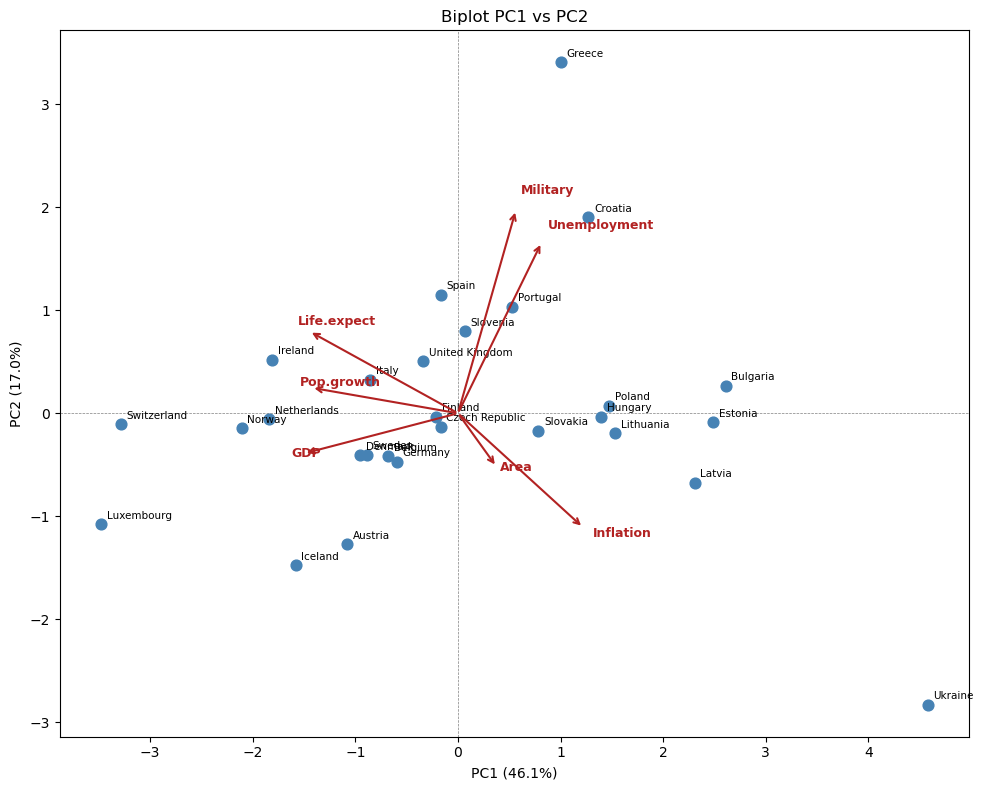

In [14]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scores
ax.scatter(scores[:, 0], scores[:, 1], s=60, color='steelblue', zorder=3)
for i, country in enumerate(countries):
    ax.annotate(country, (scores[i, 0], scores[i, 1]),
                fontsize=7.5, textcoords='offset points', xytext=(4, 4))

# Vectores de loadings escalados
scale = 3.0
for j, feat in enumerate(features):
    ax.annotate('', xy=(pca.components_[0, j] * scale, pca.components_[1, j] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.5))
    ax.text(pca.components_[0, j] * scale * 1.08,
            pca.components_[1, j] * scale * 1.08,
            feat, color='firebrick', fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot PC1 vs PC2')
plt.tight_layout()
plt.show()

Si vemos PC1 y PC2 con este plot vemos que PC1 se interessa mas a inflation, GDP, Pop.growth and life expect mientras que PC2 usa military and unployement. 

## 5. Interpretación teórica de PC1

### ¿Qué varianza captura PC1?

PC1 captura aproximadamente el 46.1% de la varianza total del dataset.

El loading de cada variable en PC1 indica cuánto y en qué dirección contribuye esa variable a la primera componente principal. Los valores más alejados de 0 (en valor absoluto) son los más relevantes.

Observando el gráfico de loadings de PC1:

Loading positivos: 
GDP  --> Paises con mayor GDB tienen mayor PC1 
Life.expect --> Mayor expectativa de vida da mayor PC1 
Pop.growth --> Paises con mayor crecimiento poblacional tiene mayor PC1 

Loading negativos:  
Inflation  --> Paises ayor inflación tienen PC1 mas bajo 
Unemployment -->  Los paises que tiene una poblacion desempleada tienen menor PC1 

Loadings cerca de 0: 
Military --> El gasto militar de los paises no influye el PC1
Area --> La area del pais no influye el PC1

### ¿Qué representa PC1?

PC1 puede interpretarse como un indice de desarollo y estabilidad de un pais. Mas un pais tiene un score de PC1 alto mas esta desarollo, estable con una situacion economica estable y mas bajo es mas es un pais con inestabilidad o con menos desarollo. Los paises que estan cercanos de ceros son paises que no tienen una inestabilidad pronunciada pero que tampoco tienen un nivel de vida lujoso tal como el luxemburgo o suiza. 

#Analisis del dataset

Algunas variables en el grafico de PC1 y PC2 nos parecian Raro, Ukrania que parece orientada unicamente por inflation y area, es un pais enorme con una inflacion importante pero que ahora esta en guerra y este score deberia influir mas ukrania. Y despues Grecia que es muy alto o por military, pero grecia no esta en guerra o por unemployed. Grecia tuvo una crisis en los anos 2010' y tuvo un score de unemployed elevado durante estos anos, pero salio de la crisis y estos features no tendrian que influir tantos.

Buscando sobre este dataset, me di cuenta que era de los anos 2012/2013, lo cual ya no refleja la situacion actual de europa. 
Decidi hacer un analisis complementaria con el nuevo dataset. 
Tambien por cuestion de orgullo agregué a Francia en esta parte de la analisis. 

In [ ]:
df_2025 = pd.read_csv('europe_2025.csv')
print(df_2025.shape)

(28, 8)


In [25]:
features = ['Area', 'GDP', 'Inflation', 'Life.expect', 'Military', 'Pop.growth', 'Unemployment']
countries = df_2025['Country'].values

X = df_2025[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pd.DataFrame(X_scaled, columns=features).round(3)

,Area,GDP,Inflation,Life.expect,Military,Pop.growth,Unemployment
0,-0.549,0.414,-0.278,0.391,-0.285,-0.343,-0.289
1,-0.855,0.325,-0.070,0.452,-0.199,0.386,-0.139
2,-0.394,-1.106,-0.153,-1.507,-0.242,-1.508,-0.627
3,-0.705,-0.746,0.719,-0.497,-0.099,-0.051,-0.214
4,-0.578,-0.400,-0.776,-0.405,-0.257,-0.692,-1.227
5,-0.783,0.636,-0.610,0.513,-0.012,0.240,-0.326
6,-0.771,-0.676,0.470,-0.926,-0.012,-0.692,0.425
7,0.908,0.103,-0.527,0.482,-0.156,-0.051,1.326
8,1.016,0.261,-0.236,0.115,-0.170,-0.780,-0.927
9,-0.274,-0.844,-0.444,0.697,0.002,-0.051,1.363


In [26]:
pca = PCA()
scores = pca.fit_transform(X_scaled)

# Varianza explicada
var_exp = pca.explained_variance_ratio_
var_acc = np.cumsum(var_exp)

print('Varianza explicada por cada componente:')
for i, (v, vc) in enumerate(zip(var_exp, var_acc)):
    print(f'  PC{i+1}: {v*100:.2f}%  (acumulada: {vc*100:.2f}%)')

Varianza explicada por cada componente:
  PC1: 58.94%  (acumulada: 58.94%)
  PC2: 21.14%  (acumulada: 80.08%)
  PC3: 10.23%  (acumulada: 90.31%)
  PC4: 5.41%  (acumulada: 95.72%)
  PC5: 2.23%  (acumulada: 97.95%)
  PC6: 1.33%  (acumulada: 99.29%)
  PC7: 0.71%  (acumulada: 100.00%)


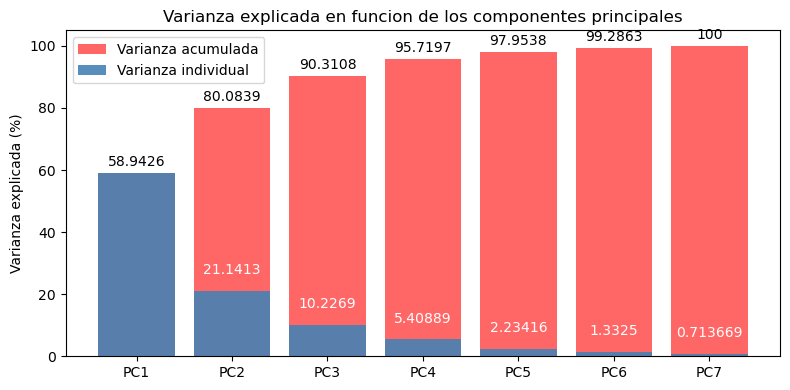

In [27]:
fig, ax = plt.subplots(figsize=(8, 4))
pcs = [f'PC{i+1}' for i in range(len(var_exp))]

barsacc = ax.bar(pcs, var_acc * 100, color='red', alpha = 0.6,label='Varianza acumulada')
ax.bar_label(barsacc, padding=3, color="black")
barsex= ax.bar(pcs, var_exp * 100, color='steelblue', alpha=0.9, label='Varianza individual')
ax.bar_label(barsex, padding=10, color=  "white")
ax.set_ylabel('Varianza explicada (%)')
ax.set_title('Varianza explicada en funcion de los componentes principales')
ax.legend()
plt.tight_layout()
plt.show()

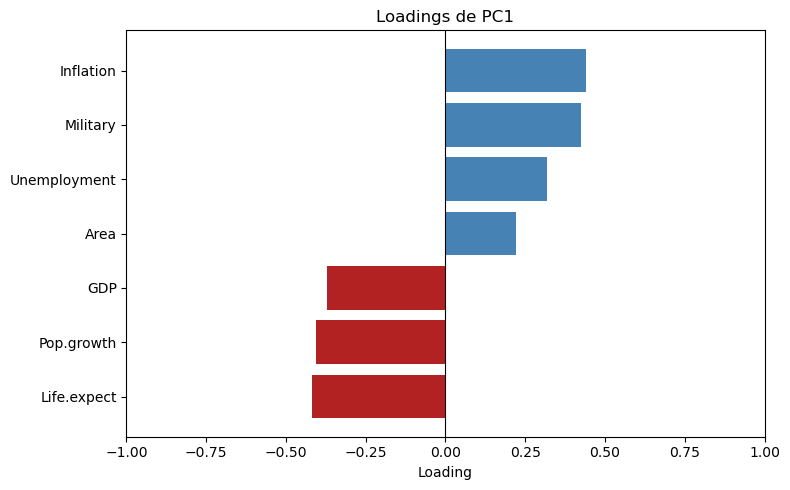


Loadings PC1:
Area            0.2203
GDP            -0.3707
Inflation       0.4404
Life.expect    -0.4175
Military        0.4254
Pop.growth     -0.4053
Unemployment    0.3170
Name: PC1, dtype: float64


In [28]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=features,
    columns=[f'PC{i+1}' for i in range(len(features))]
)

pc1_loadings = loadings['PC1'].sort_values()

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['firebrick' if v < 0 else 'steelblue' for v in pc1_loadings]
ax.barh(pc1_loadings.index, pc1_loadings.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Loading')
ax.set_title(f'Loadings de PC1')
ax.set_xlim(-1, 1)
plt.tight_layout()
plt.show()

print('\nLoadings PC1:')
print(loadings['PC1'].round(4))

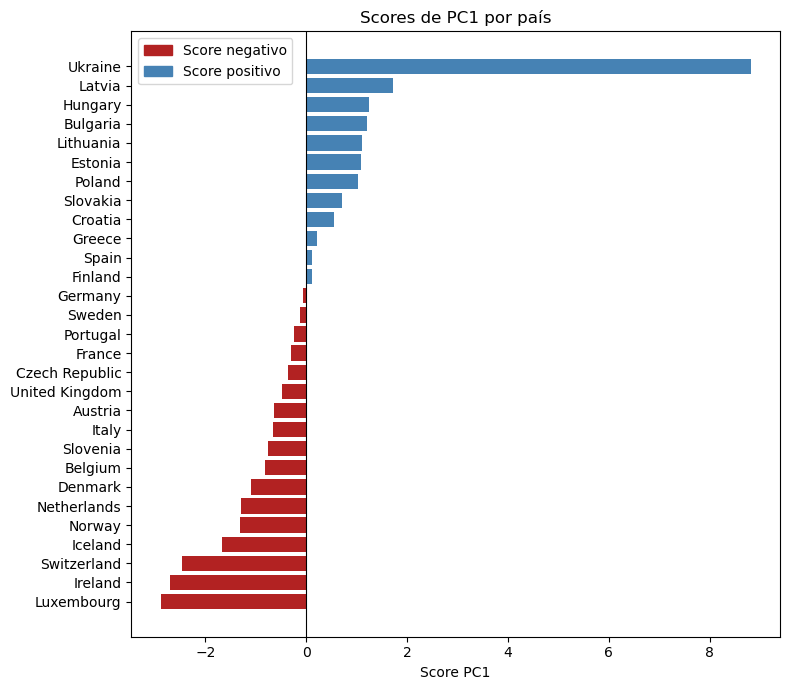

In [29]:
pc1_scores = pd.Series(scores[:, 0], index=countries).sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
colors = ['firebrick' if v < 0 else 'steelblue' for v in pc1_scores]
ax.barh(pc1_scores.index, pc1_scores.values, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Score PC1')
ax.set_title('Scores de PC1 por país')

neg = mpatches.Patch(color='firebrick', label='Score negativo')
pos = mpatches.Patch(color='steelblue', label='Score positivo')
ax.legend(handles=[neg, pos])
plt.tight_layout()
plt.show()

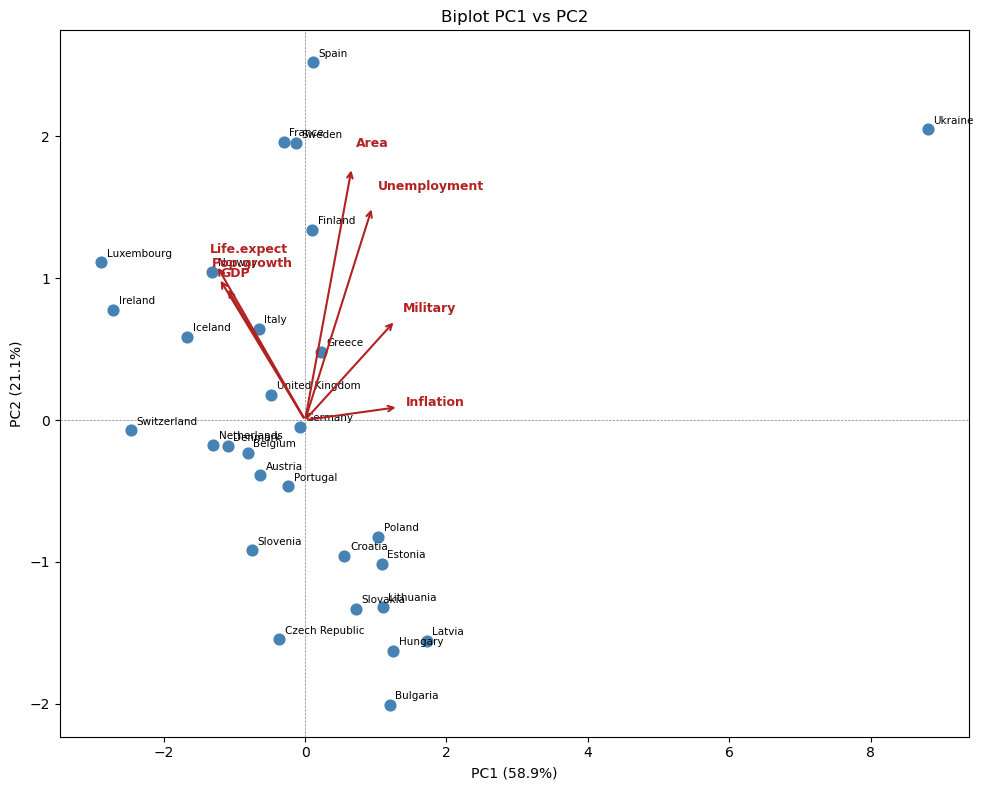

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))

# Scores
ax.scatter(scores[:, 0], scores[:, 1], s=60, color='steelblue', zorder=3)
for i, country in enumerate(countries):
    ax.annotate(country, (scores[i, 0], scores[i, 1]),
                fontsize=7.5, textcoords='offset points', xytext=(4, 4))

# Vectores de loadings escalados
scale = 3.0
for j, feat in enumerate(features):
    ax.annotate('', xy=(pca.components_[0, j] * scale, pca.components_[1, j] * scale),
                xytext=(0, 0),
                arrowprops=dict(arrowstyle='->', color='firebrick', lw=1.5))
    ax.text(pca.components_[0, j] * scale * 1.08,
            pca.components_[1, j] * scale * 1.08,
            feat, color='firebrick', fontsize=9, fontweight='bold')

ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_xlabel(f'PC1 ({var_exp[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({var_exp[1]*100:.1f}%)')
ax.set_title('Biplot PC1 vs PC2')
plt.tight_layout()
plt.show()

Esta visualizacion refleja mas el estado europeo actual.
Los loadings del PC1 son : 

Positivo: 
Inflation --> Paises con mayor inflacion tiene PC1 mas alto
Military  --> Paises con presupuesto militar mas alto tiene PC1 mas alto
Unemployment --> Paises con alto nivel de desemplo tiene PC1 mas alto   
Area  --> Paises con area mas importane tiene PC1 mas alto       


Negativo:
GDP    --> Paises con mayor GDB tiene menor PC1        
Life.expect  --> Paises con mayor expectiva de vida da menor PC1  
Pop.growth   --> Paises con mayor crecimiento poblacional tiene menor PC1


Ukrania esta esta vez arriba a la derecha, por la guerra el pais tiene una inflacion alta, con un nivel de desempleo elevado y mas que todo un budgeto militar importante. Grecia y croatia se acercaron mas al centro, el desemplo parece haber bajado. Este nuevo grafico es mas representativo de la Europa actual. 